## Atividade Cap 06 - Módulo de Matemática e Estatística Aplicada Para Data Science, Machine Learning e IA, Data Science Academy ##

In [1]:
# Importando bibliotecas necessárias para resolução do exercício

import numpy as np
import math
from sympy import symbols, Eq, solve
import matplotlib.pyplot as plt


Exercício: Produto Escalar em Aplicação Prática

Descrição:  Dados  dois  vetores  que  representam  preferências  de  usuários  em  três categorias diferentes user1 = [4, 3, 2] e user2 = [1, 5, 4], calcule a similaridade entre esses usuários usando o produto escalar.

In [2]:
#resposta 1 

user1 = [4, 3, 2]
user2 = [1, 5, 4]

similaridade = np.dot(user1, user2)
print(similaridade)

27


Exercício 2: Multiplicação de Escalar por Vetor em Dados Reais

Descrição: Dada uma série de preços de ações prices = [120, 125, 130, 128, 135], ajuste os preços em 15% e calcule o novo preço das ações.

In [7]:
#resposta

prices = np.array([120, 125, 130, 128, 135])

# o valor escalar representa 100% do valor original + 15% de aumento.
scalar_value = 1.15

new_prices = scalar_value * prices

print(new_prices)



[138.   143.75 149.5  147.2  155.25]


Exercício 3: Otimização de Produto Escalar

Descrição: Encontre o vetor unitário que maximiza o produto escalar com o vetor v = [3, 4, 5]. Use técnicas de otimização para encontrar a solução.

In [14]:
#reposta1

v = np.array([3, 4, 5])

u_otimo = v / math.sqrt(sum(x**2 for x in v))

print(u_otimo)
vetormax = np.dot(v,u_otimo)
print(vetormax)


[0.42426407 0.56568542 0.70710678]
7.0710678118654755


In [11]:
#resposta2 utilizando otimização

v = np.array([3, 4, 5])

#definindo variáveis simbólicas
u1 = symbols('u1')
u2 = symbols('u2')
u3 = symbols('u3')
L = symbols('L') # L = Lambda

u = [u1, u2, u3]

# Maximizarf(u) = v * u

f = np.dot(v, u)

print(f)

# Como u deve ser unitário, sua norma deve ser igual a 1, ou seja:
u_unitario = u1**2 + u2**2 + u3**2 - 1

#utilizando a fórmula geral de Lagrange:
lagrange = f - L * u_unitario
print(lagrange)

#utilizando derivadas para otimização:
eq1 = Eq(lagrange.diff(u1), 0) #igualando a 0.
eq2 = Eq(lagrange.diff(u2), 0)
eq3 = Eq(lagrange.diff(u3), 0)
eq4 = Eq(lagrange.diff(L), 0)

print(eq1)
print(eq2)
print(eq3)
print(eq4)

#Resolvendo o sistema de equações:
solucoes = solve((eq1, eq2, eq3, eq4), (u1, u2, u3, L))
for i in solucoes:
    u = (float(i[0]) , float(i[1]) , float(i[2]))

print(u)

valor_max = np.dot(v, u)
print(f"Valor Máx: {valor_max}")

3*u1 + 4*u2 + 5*u3
-L*(u1**2 + u2**2 + u3**2 - 1) + 3*u1 + 4*u2 + 5*u3
Eq(-2*L*u1 + 3, 0)
Eq(-2*L*u2 + 4, 0)
Eq(-2*L*u3 + 5, 0)
Eq(-u1**2 - u2**2 - u3**2 + 1, 0)
(0.4242640687119285, 0.565685424949238, 0.7071067811865476)
Valor Máx: 7.0710678118654755


In [8]:
#Como o professor resolveu: 

from scipy.optimize import minimize

# Array
v = np.array([3, 4, 5])

# Função objetivo
def funcao_objetivo(x):
    return -np.dot(v, x)

# Restrição para garantir que o vetor seja unitário
constraint = {'type': 'eq', 'fun': lambda x: np.linalg.norm(x) - 1}

# Solução de otimização
resultado = minimize(funcao_objetivo, np.ones(3), constraints = constraint)
vetor_otimizado = resultado.x

print(vetor_otimizado)
# Calculando o produto escalar entre o vetor inicial e o vetor resultante
produto_escalar = np.dot(v, vetor_otimizado)
produto_escalar


[0.42427229 0.56568116 0.70710527]


np.float64(7.07106783485059)

Exercício 4: Produto Vetorial e Direção Normal

Descrição:  Dados  três  pontos  no  espaço  3D  A  =  [1,  2,  3],  B  =  [4,  5,  6],  e  C  =  [7,  8,  9], encontre um vetor normal ao plano definido por esses três pontos.


In [20]:
#resposta
A = np.array([1, 2, 3])
B = np.array([4, 5, 6])
C = np.array([7, 8, 9])

def encontrar_vetor (x, y, z):
    #formando dois vetores contidos no plano
    v1 = x - y
    v2 = x - z
    #produto entre os dois vetores
    return np.cross(v1, v2)

print(encontrar_vetor(A, B, C))   


[0 0 0]


Exercício 5: Produto Vetorial em Análise de Dados

Descrição: Em um conjunto de dados 3D com pontos p1 = [1, 2, 3], p2 = [4, 5, 6], e p3 = [7, 8, 9], encontre o vetor normal ao plano formado por esses três pontos e interprete seu significado em termos de orientação do plano.

In [21]:
#resposta 
p1 = np.array([1, 2, 3])
p2 = np.array([4, 5, 6])
p3 = np.array([7, 8, 9])

vetor1 = p1 - p2
vetor2 = p1 - p3
print(f"Vetor 1 = {vetor1}")
print(f"Vetor 2 = {vetor2}")
print(f"Vetor Normal: {encontrar_vetor(p1, p2, p3)}")

Vetor 1 = [-3 -3 -3]
Vetor 2 = [-6 -6 -6]
Vetor Normal: [0 0 0]


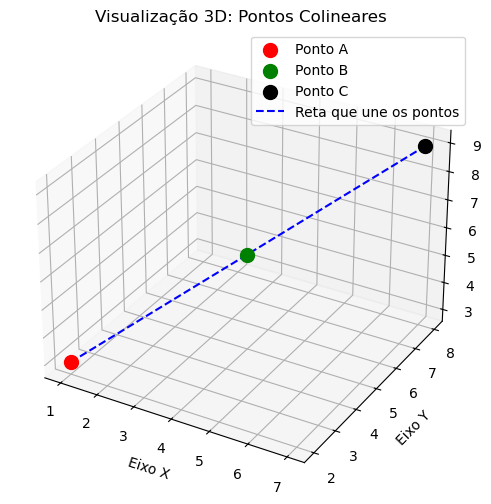

In [23]:
# Preparando a figura 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Extraindo coordenadas
pontos = np.array([A, B, C])
x = pontos[:, 0]
y = pontos[:, 1]
z = pontos[:, 2]

# Plotando os pontos
ax.scatter(A[0], A[1], A[2], color='red', s=100, label='Ponto A')
ax.scatter(B[0], B[1], B[2], color='green', s=100, label='Ponto B')
ax.scatter(C[0], C[1], C[2], color='black', s=100, label='Ponto C')

# Linha mostrando a colinearidade
ax.plot(x, y, z, color='blue', linestyle='--', label='Reta que une os pontos')

# Configuração
ax.set_xlabel('Eixo X')
ax.set_ylabel('Eixo Y')
ax.set_zlabel('Eixo Z')
ax.set_title('Visualização 3D: Pontos Colineares')
ax.legend()

plt.show()

**Interpretação:**

Os vetores obtidos a partir dos pontos são múltiplos entre si, portanto são linearmente dependentes e colineares. Isso confirma que os três pontos estão alinhados sobre a mesma reta e, consequentemente, não definem um plano único no espaço tridimensional. Por esse motivo, o produto vetorial entre os vetores gera o vetor nulo [0,0,0].

Do ponto de vista geométrico, o vetor normal nulo indica a inexistência de uma orientação de plano, pois os dados apresentam apenas uma direção dominante no espaço.

Sob a ótica de análise de dados, esse comportamento revela que a variação observada ocorre em apenas uma dimensão efetiva, apesar de os dados estarem representados em três variáveis. Isso caracteriza redundância informacional e dependência linear entre atributos, um cenário que pode causar instabilidade numérica em modelos estatísticos e algoritmos de Machine Learning, como regressão linear, devido à multicolinearidade.

Uma abordagem robusta para tratar esse problema é a aplicação de Principal Component Analysis. Essa técnica transforma variáveis possivelmente correlacionadas em novas variáveis ortogonais e linearmente independentes, denominadas componentes principais.

Neste caso específico, o PCA identificaria que a primeira componente principal concentra 100% da variância dos dados, enquanto as demais componentes teriam variância nula. Isso permite reduzir a representação de 3D para 1D sem perda de informação, preservando totalmente a estrutura dos dados e removendo a redundância de maneira eficiente.
